# Model Proportion Analysis

Loads models via SSH, extracts `best_tp` from `model.metrics`, and visualizes:
- Histogram of `best_tp` values
- Matrix of `best_tp` as a function of loss and target

In [1]:
import sys
import os
import io
import math
import pickle
import itertools
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import paramiko
import logging

import sys

sys.path.insert(0, '/home/caron/Bureau/ST-GNN-for-wildifre-prediction/Prediction')
sys.path.insert(0, '/home/caron/Bureau/ST-GNN-for-wildifre-prediction/Prediction/GNN')

logging.basicConfig(level=logging.WARNING)

import forecasting_models


## Configuration

Select `dataset = 'firemen'` or `dataset = 'bdiff'`.

In [2]:
# ── CHOOSE DATASET ────────────────────────────────────────────────────────
dataset = 'firemen'   # 'firemen' or 'bdiff'

# ── DATASET-SPECIFIC SETTINGS ─────────────────────────────────────────────
if dataset == 'firemen':
    base_path = Path('firemen/firepoint/2x2/train/occurence_01_06_25/check_z-score/full_all_3_0_risk-size-zonemeteo-degree-a3-r5-t0.3_node/')
    clustering = 'quantile'
    losses = [
        #'regression_pdegpd',
        #'classification_flwki-id{departement}',
        #'classification_flwk',
        #'classification_weightedcrossentropy',
        #'classification_wkloss',
        #'classification_bceloss',
        #'classification_fl',
        #'regression_cll',
        'regression_ccllt-id{node}-nclusters{30}',
        #'regression_ccllt2-id{node}-nclusters{30}',
    ]
    targets = [
        f'nbsinister-{clustering}-5-Class-Dept',
        f'timeintervention-{clustering}-5-Class-Dept',
        f'ressource-{clustering}-5-Class-Dept',
    ]
    targets_ccllt = ['nbsinister', 'ressource', 'timeintervention']
    losses_ccllt  = ['regression_ccllt-id{node}-nclusters{30}', 'regression_ccllt2-id{node}-nclusters{30}']

elif dataset == 'bdiff':
    base_path = Path('bdiff/firepoint/2x2/train/occurence_default/check_z-score/full_all_departement_0_None_node/')
    clustering = 'kmeans'
    losses = [
        'regression_pdegpd',
        'regression_cll',
    ]
    targets = [
        f'burnedareaRoot-{clustering}-5-Class-Dept',
    ]
    targets_ccllt = ['burnedareaRoot']
    losses_ccllt  = ['regression_ccllt-id{node}-nclusters{95}']

else:
    raise ValueError(f"Unknown dataset: {dataset}. Choose 'firemen' or 'bdiff'.")

models = ['GRU_search_full_10_0_all_one_']

all_dir       = list(itertools.product(models, losses, targets))
all_dir_ccllt = list(itertools.product(models, losses_ccllt, targets_ccllt))
all_dir_full  = all_dir + all_dir_ccllt

print(f"Dataset     : {dataset}")
print(f"Base path   : {base_path}")
print(f"Total combos: {len(all_dir_full)}")

Dataset     : firemen
Base path   : firemen/firepoint/2x2/train/occurence_01_06_25/check_z-score/full_all_3_0_risk-size-zonemeteo-degree-a3-r5-t0.3_node
Total combos: 9


## Load Models via SSH

Connects to the remote server, finds matching model directories, loads each model `.pkl` file, and extracts `metrics['best_tp']`.

In [ ]:
# ── SSH HELPERS ───────────────────────────────────────────────────────────
def list_remote_model_files(sftp, remote_dir):
    """Return the first .pkl file found in remote_dir/H0 or remote_dir."""
    for subdir in [remote_dir.rstrip('/') + '/H0', remote_dir]:
        try:
            files = [f for f in sftp.listdir(subdir) if f.endswith('.pkl')]
            if files:
                return [subdir + '/' + files[0]]
        except FileNotFoundError:
            pass
    return []

def read_remote_pickle(sftp, path):
    with sftp.open(path, 'rb') as f:
        data = f.read()
    return pickle.load(io.BytesIO(data))

def find_remote_directories(sftp, base_remote, combos):
    """Return list of (full_path, model, loss, target) for existing dirs."""
    matches = []
    try:
        sftp.listdir(base_remote)
    except FileNotFoundError:
        print(f"Base path not found on remote: {base_remote}")
        return matches
    for (model, loss, target) in combos:
        dir_name  = f"{model}{target}_{loss}"
        full_path = base_remote.rstrip('/') + '/' + dir_name
        try:
            sftp.listdir(full_path)
            matches.append((full_path, model, loss, target))
        except FileNotFoundError:
            pass
    return matches


# ── SSH CONNECTION ────────────────────────────────────────────────────────
hostname = "mesohelios1.univ-fcomte.fr"
username = "ncaron"
password = "xp2nrfeu"

ssh = paramiko.SSHClient()
ssh.set_missing_host_key_policy(paramiko.AutoAddPolicy())
ssh.connect(hostname, username=username, password=password)
sftp = ssh.open_sftp()

# ── FIND DIRECTORIES ─────────────────────────────────────────────────────
gnn_path    = Path('/Home/Users/ncaron/WORK/GNN')
base_remote = (gnn_path / base_path).as_posix()
directories = find_remote_directories(sftp, base_remote, all_dir_full)
print(f"Found {len(directories)} matching directories.")

# ── LOAD best_tp ─────────────────────────────────────────────────────────
records = []
for full_path, model, loss, target in directories:
    pkl_files = list_remote_model_files(sftp, full_path)
    if not pkl_files:
        print(f"  No .pkl found in {full_path}")
        continue
    try:
        obj = read_remote_pickle(sftp, pkl_files[0])
    except Exception as e:
        print(f"  Error loading {full_path}: {e}")
        continue
    
    # Support both model objects (with .metrics) and plain dicts
    if hasattr(obj, 'metrics'):
        metrics = obj.metrics
    elif isinstance(obj, dict):
        metrics = obj
    else:
        print(f"  No 'metrics' attribute in {full_path}")
        continue

    best_tp = metrics.get('best_tp', None)
    if best_tp is None:
        print(f"  'best_tp' not in metrics for {full_path}")
        continue

    # Derive a clean loss label (strip prefix regression_/classification_)
    loss_label = loss.split('_', 1)[-1] if '_' in loss else loss
    
    records.append({
        'model'   : model,
        'loss'    : loss,
        'loss_label': loss_label,
        'target'  : target,
        'best_tp' : float(best_tp),
        'path'    : full_path,
    })
    print(f"  OK  {loss:<45}  {target:<40}  best_tp={best_tp:.4f}")

sftp.close()
ssh.close()

df_best_tp = pd.DataFrame(records)
print(f"\nLoaded best_tp for {len(df_best_tp)} model configurations.")
df_best_tp.head()


Found 3 matching directories.


/tmp/ipykernel_1129997/4018384133.py:16: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  return pickle.load(io.BytesIO(data))


  OK  regression_ccllt-id{node}-nclusters{30}        nbsinister                                best_tp=0.4000
  OK  regression_ccllt-id{node}-nclusters{30}        timeintervention                          best_tp=0.1000


/home/caron/anaconda3/envs/venv-3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  Error loading /Home/Users/ncaron/WORK/GNN/firemen/firepoint/2x2/train/occurence_01_06_25/check_z-score/full_all_3_0_risk-size-zonemeteo-degree-a3-r5-t0.3_node/GRU_search_full_10_0_all_one_timeintervention_regression_ccllt2-id{node}-nclusters{30}: No module named 'reformer_pytorch'

Loaded best_tp for 2 model configurations.


,model,loss,loss_label,target,best_tp,path
0,GRU_search_full_10_0_all_one_,regression_ccllt-id{node}-nclusters{30},ccllt-id{node}-nclusters{30},nbsinister,0.4,/Home/Users/ncaron/WORK/GNN/firemen/firepoint/...
1,GRU_search_full_10_0_all_one_,regression_ccllt-id{node}-nclusters{30},ccllt-id{node}-nclusters{30},timeintervention,0.1,/Home/Users/ncaron/WORK/GNN/firemen/firepoint/...


In [4]:
df_best_tp

,model,loss,loss_label,target,best_tp,path
0,GRU_search_full_10_0_all_one_,regression_ccllt-id{node}-nclusters{30},ccllt-id{node}-nclusters{30},nbsinister,0.4,/Home/Users/ncaron/WORK/GNN/firemen/firepoint/...
1,GRU_search_full_10_0_all_one_,regression_ccllt-id{node}-nclusters{30},ccllt-id{node}-nclusters{30},timeintervention,0.1,/Home/Users/ncaron/WORK/GNN/firemen/firepoint/...


## Histogram of `best_tp`

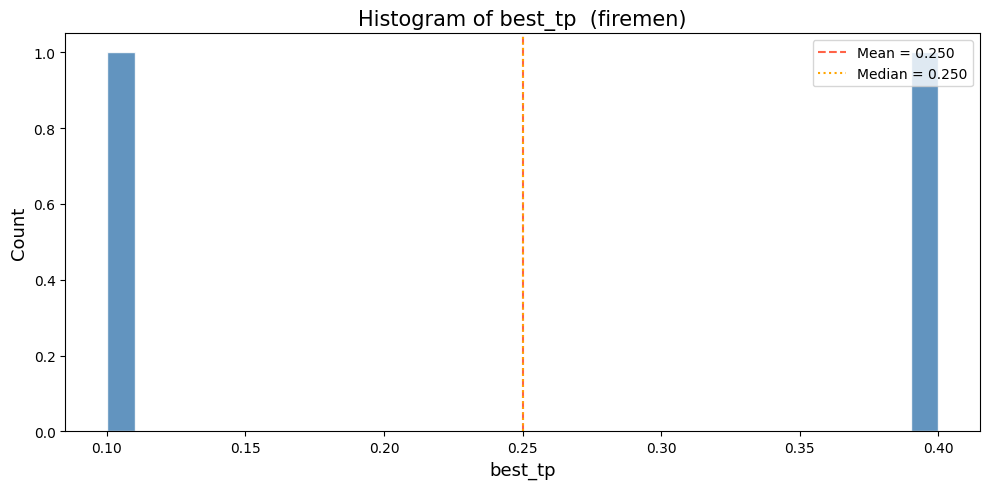

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(df_best_tp['best_tp'].dropna(), bins=30, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(df_best_tp['best_tp'].mean(), color='tomato', linestyle='--', linewidth=1.5, label=f"Mean = {df_best_tp['best_tp'].mean():.3f}")
ax.axvline(df_best_tp['best_tp'].median(), color='orange', linestyle=':', linewidth=1.5, label=f"Median = {df_best_tp['best_tp'].median():.3f}")

ax.set_xlabel('best_tp', fontsize=13)
ax.set_ylabel('Count', fontsize=13)
ax.set_title(f'Histogram of best_tp  ({dataset})', fontsize=15)
ax.legend()
fig.tight_layout()
plt.show()


## Matrix: `best_tp` by Loss × Target

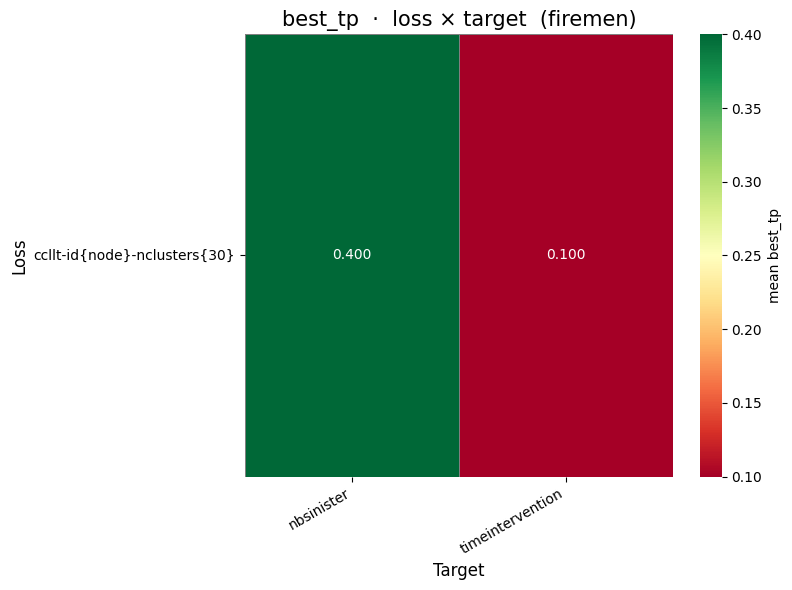

Pivot table:


target,nbsinister,timeintervention
loss_label,,
ccllt-id{node}-nclusters{30},0.4,0.1


In [6]:
if df_best_tp.empty:
    print("No data to plot.")
else:
    # Pivot: rows = loss_label, columns = target, values = mean best_tp
    pivot = df_best_tp.pivot_table(
        index='loss_label',
        columns='target',
        values='best_tp',
        aggfunc='mean'
    )

    fig, ax = plt.subplots(figsize=(max(8, len(pivot.columns) * 2.5), max(6, len(pivot) * 0.7)))
    sns.heatmap(
        pivot,
        annot=True,
        fmt='.3f',
        cmap='RdYlGn',
        linewidths=0.5,
        linecolor='grey',
        cbar_kws={'label': 'mean best_tp'},
        ax=ax
    )
    ax.set_title(f'best_tp  ·  loss × target  ({dataset})', fontsize=15)
    ax.set_xlabel('Target', fontsize=12)
    ax.set_ylabel('Loss', fontsize=12)
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
    plt.setp(ax.get_yticklabels(), rotation=0)
    fig.tight_layout()
    plt.show()

    print("Pivot table:")
    display(pivot.round(4))


## Distribution of `best_tp` per Loss (boxplot)

/tmp/ipykernel_1129997/1852419883.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_best_tp, x='loss_label', y='best_tp', order=order,


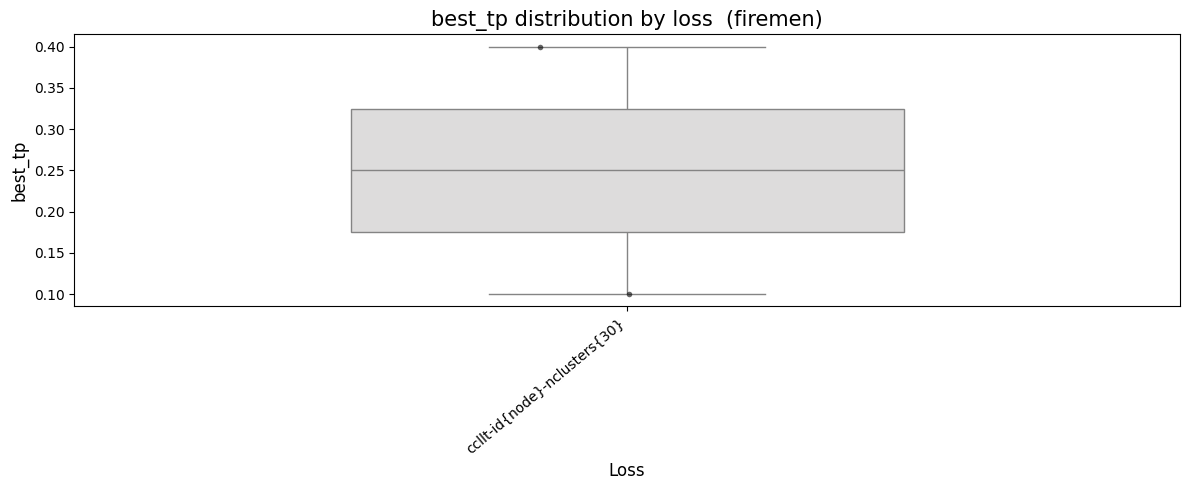

In [7]:
if not df_best_tp.empty:
    order = df_best_tp.groupby('loss_label')['best_tp'].median().sort_values(ascending=False).index

    fig, ax = plt.subplots(figsize=(12, 5))
    sns.boxplot(data=df_best_tp, x='loss_label', y='best_tp', order=order,
                palette='coolwarm', width=0.5, ax=ax)
    sns.stripplot(data=df_best_tp, x='loss_label', y='best_tp', order=order,
                  color='black', size=4, alpha=0.6, jitter=True, ax=ax)

    ax.set_title(f'best_tp distribution by loss  ({dataset})', fontsize=15)
    ax.set_xlabel('Loss', fontsize=12)
    ax.set_ylabel('best_tp', fontsize=12)
    plt.setp(ax.get_xticklabels(), rotation=40, ha='right')
    fig.tight_layout()
    plt.show()
